In [1]:
##### Import
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.datasets import mnist
from sklearn.metrics import confusion_matrix
import seaborn as sns
np.random.seed(42)

In [2]:
###### Carregando os dados
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

11490434/11490434 [==============================] - 2s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [11]:
y_test[90]

3

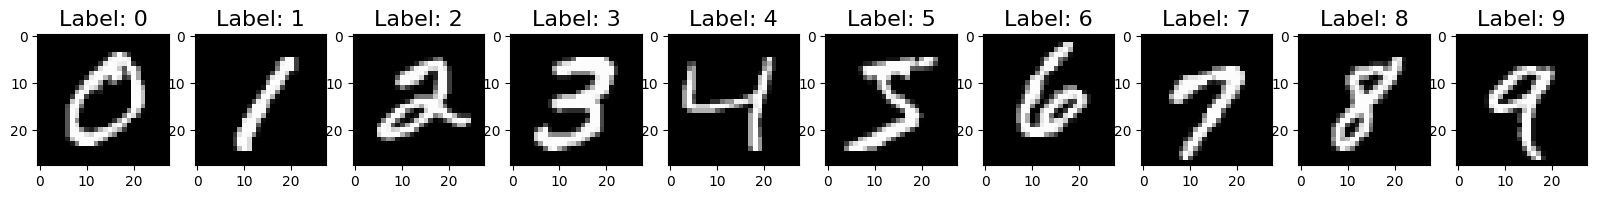

In [12]:
##### Vizualizando os dados
num_classes = 10
f, ax = plt.subplots(1, num_classes, figsize=(20,20))

for i in range(0, num_classes):
  sample = x_train[y_train == i][0]
  ax[i].imshow(sample, cmap='gray')
  ax[i].set_title("Label: {}".format(i), fontsize=16)

In [5]:
##### Printando resultado
for i in range(10):
  print(y_train[i])

5
0
4
1
9
2
1
3
1
4


In [13]:
##### Mudando o formato dos nossos dados
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [7]:
for i in range(10):
  print(y_train[i])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [14]:
####### Preparando os dados

In [15]:
# Normalizando
x_train = x_train / 255.0
x_test = x_test / 255.0

In [16]:
# Reshape Data
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
print(x_train.shape)

(60000, 784)


In [ ]:
#### Criando o modelo - Rede Neural

In [17]:
model = Sequential()

model.add(Dense(units=128, input_shape=(784,), activation='relu'))
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(units=10, activation='softmax'))

model.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary ()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 10)                1290      
                                                                 
Total params: 118282 (462.04 KB)
Trainable params: 118282 (462.04 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [18]:
### Treinando o modelo
batch_size = 512
epochs = 10
model.fit(x=x_train, y=y_train, batch_size=batch_size, epochs=epochs)

Epoch 1/10
118/118 [==============================] - 4s 4ms/step - loss: 0.6089 - accuracy: 0.8226
Epoch 2/10
118/118 [==============================] - 0s 4ms/step - loss: 0.2254 - accuracy: 0.9339
Epoch 3/10
118/118 [==============================] - 0s 4ms/step - loss: 0.1623 - accuracy: 0.9521
Epoch 4/10
118/118 [==============================] - 0s 4ms/step - loss: 0.1298 - accuracy: 0.9616
Epoch 5/10
118/118 [==============================] - 0s 4ms/step - loss: 0.1066 - accuracy: 0.9683
Epoch 6/10
118/118 [==============================] - 0s 4ms/step - loss: 0.0918 - accuracy: 0.9727
Epoch 7/10
118/118 [==============================] - 0s 4ms/step - loss: 0.0790 - accuracy: 0.9765
Epoch 8/10
118/118 [==============================] - 0s 4ms/step - loss: 0.0700 - accuracy: 0.9790
Epoch 9/10
118/118 [==============================] - 0s 4ms/step - loss: 0.0618 - accuracy: 0.9814
Epoch 10/10
118/118 [==============================] - 0s 4ms/step - loss: 0.0538 - accuracy: 0.9836

In [19]:
# Evaluando

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Loss: {}, Test Accuracy:{}".format(test_loss, test_acc))

313/313 [==============================] - 1s 2ms/step - loss: 0.0801 - accuracy: 0.9756
Test Loss: 0.08008269220590591, Test Accuracy:0.975600004196167


In [20]:
y_pred = model.predict((x_test))
y_pred_classes = np.argmax(y_pred, axis=1)
print(y_pred)
print(y_pred_classes)

313/313 [==============================] - 1s 2ms/step
[[2.73908427e-07 1.57060254e-06 6.64690160e-05 ... 9.99721229e-01
  1.26311033e-06 3.92056099e-05]
 [2.62883503e-07 2.61932495e-04 9.99610364e-01 ... 4.80922635e-09
  1.65156041e-06 3.72424358e-09]
 [6.04222223e-05 9.95828450e-01 1.06396829e-03 ... 1.03648868e-03
  1.12073659e-03 5.23801418e-06]
 ...
 [2.50109405e-10 4.66359662e-09 2.42963449e-09 ... 2.74309537e-06
  3.15095576e-07 5.35152903e-05]
 [1.02558758e-07 1.86035276e-08 5.65505087e-10 ... 1.18756338e-09
  4.60294279e-04 3.53313645e-09]
 [2.03120777e-07 3.00313281e-11 1.59199072e-08 ... 1.19154174e-11
  5.37116129e-08 5.44015819e-08]]
[7 2 1 ... 4 5 6]


In [21]:
print(y_pred[0])
print(np.argmax(y_pred[0]))

[2.73908427e-07 1.57060254e-06 6.64690160e-05 1.68585946e-04
 1.11010436e-07 1.17024229e-06 1.12222076e-09 9.99721229e-01
 1.26311033e-06 3.92056099e-05]
7


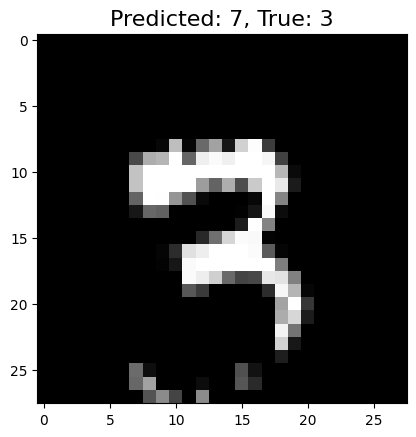

In [26]:
# Exemplo

random_idx = np.random.choice(len(x_test))
x_sample = x_test[random_idx]
y_true = np.argmax(y_test, axis=1)
y_sample_true = y_true[random_idx]
y_sample_pred_class = y_pred_classes[random_idx]

plt.title("Predicted: {}, True: {}".format(y_sample_pred_class, y_sample_true), fontsize=16)
plt.imshow(x_sample.reshape(28, 28), cmap='gray')

Text(0.5, 1.0, 'Confusion Matrix')

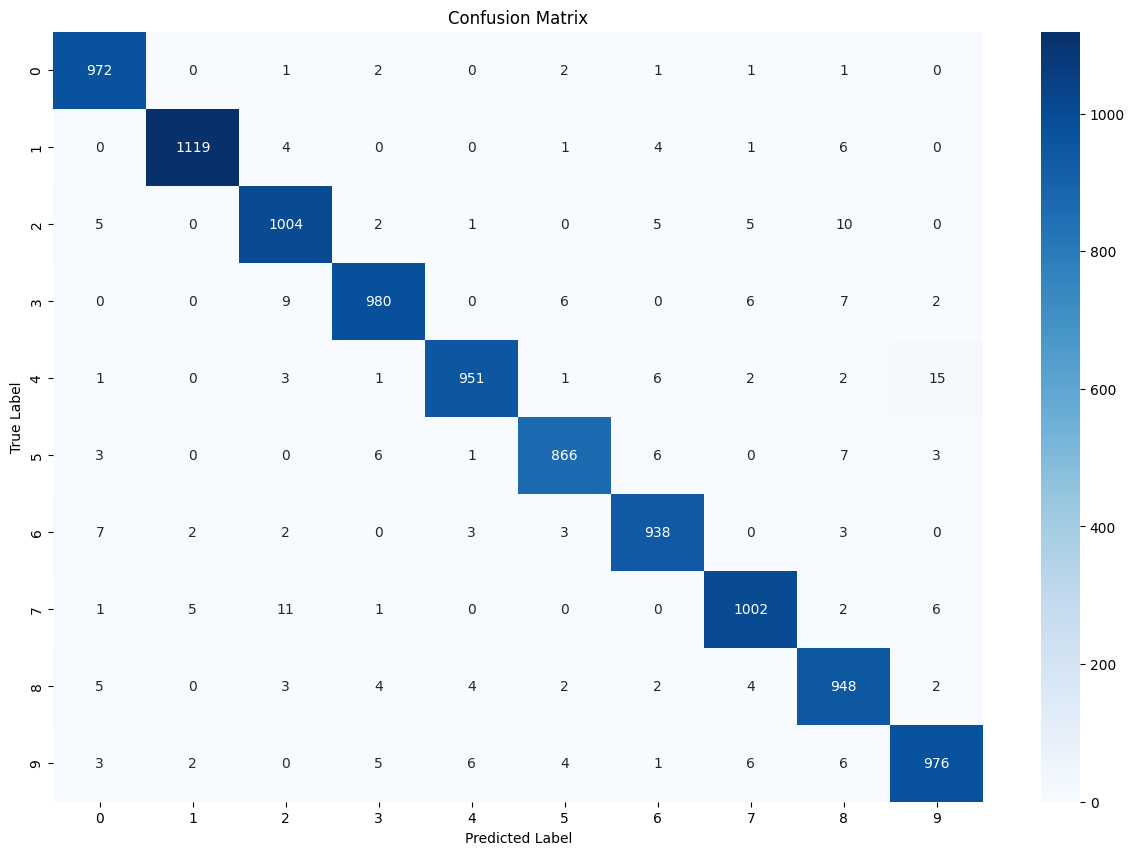

In [27]:
#### Matrix de confusão


confusion_mtx = confusion_matrix(y_true, y_pred_classes)

# Plot

fig, ax = plt.subplots(figsize=(15,10))
ax = sns.heatmap(confusion_mtx, annot=True, fmt='d', ax=ax, cmap="Blues")
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')

In [28]:
errors = (y_pred_classes - y_true != 0)
y_pred_classes_errors = y_pred_classes[errors]
y_pred_errors = y_pred[errors]
y_true_errors = y_true[errors]
x_test_errors = x_test[errors]

In [ ]:

y_pred_errors_probability = np.max(y_pred_errors, axis=1)
true_probability_errors = np.diagonal(np.take(y_pred_errors, y_true_errors, axis=1))
diff_errors_pred_true = y_pred_errors_probability - true_probability_errors

# Get list of indices of sorted differences
sorted_idx_diff_errors = np.argsort(diff_errors_pred_true)
top_idx_diff_errors = sorted_idx_diff_errors[-10:] # 5 last ones

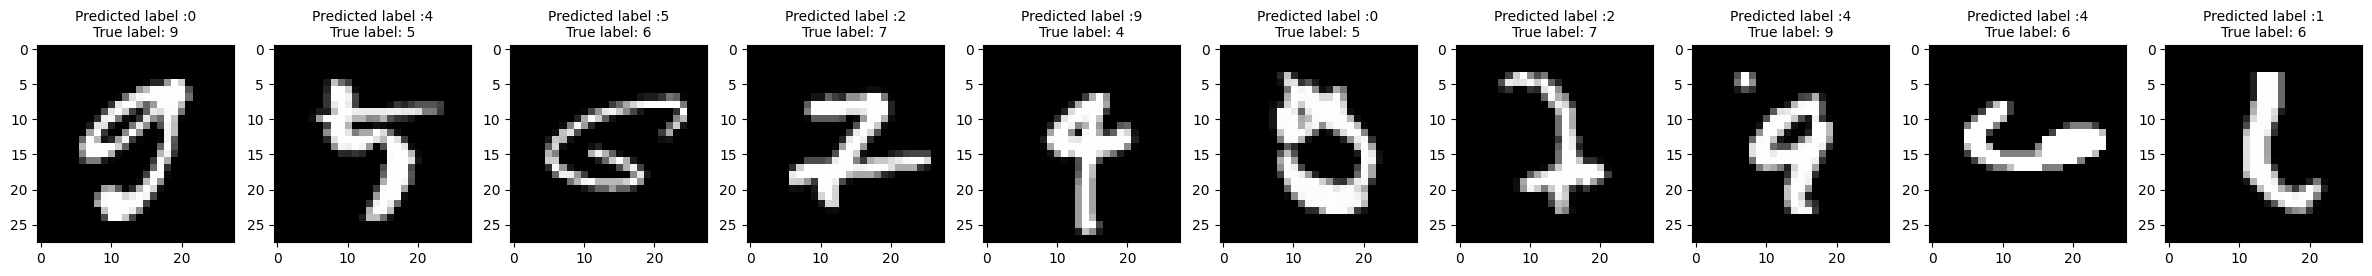

In [ ]:
# Show Top Errors
num = len(top_idx_diff_errors)
f, ax = plt.subplots(1, num, figsize=(30,30))

for i in range(0, num):
  idx = top_idx_diff_errors[i]
  sample = x_test_errors[idx].reshape(28,28)
  y_t = y_true_errors[idx]
  y_p = y_pred_classes_errors[idx]
  ax[i].imshow(sample, cmap='gray')
  ax[i].set_title("Predicted label :{}\nTrue label: {}".format(y_p, y_t), fontsize=10)

In [ ]:
from google.colab.patches import cv2_imshow
##### Vizualizando os dados
num_classes = 1
sample = abs(x_test[0]-1)*255
cv2_imshow(sample)


In [ ]:
cv2_imshow(x_test[0].reshape(28,28)*255)

In [ ]:
amostra = (x_test[0].reshape(28,28)*255)
invert = cv2.bitwise_not((amostra))
cv2_imshow(invert)

In [ ]:
# Convert the amostra variable to uint8 data type
amostra = np.uint8(amostra)

# Invert the colors of the image using bitwise_not
invert = cv2.bitwise_not(amostra)

# Display the inverted image
cv2_imshow(invert)

In [ ]:
import cv2
image = cv2.imread('/content/estrela.png',  cv2.IMREAD_GRAYSCALE)
sample_estrela = image/255
print(sample_estrela)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
  0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 1

In [ ]:
sample_estrela_reshape = sample_estrela.reshape(1, 784)
print(sample_estrela_reshape)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
  1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 

In [ ]:
result = model.predict(invert.reshape(1,784))
print(result)

1/1 [==============================] - 0s 28ms/step
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


In [ ]:
# Reshape the sample variable to have a rank of 2
sample_reshaped = sample.reshape(1, 784)

# Predict the class probabilities for the reshaped sample
result = model.predict(sample_reshaped)

# Print the result
print(result)

1/1 [==============================] - 0s 22ms/step
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


In [ ]:
lista = []
s
